**STEP-01: Data Ingestion and AAMI Mapping**

In [1]:
# ============================================================
# STEP-01: MIT-BIH Data Ingestion and AAMI Mapping
# ============================================================
!pip install wfdb
import os
import pickle
import numpy as np
import wfdb


AAMI_MAP = {
    'N': 'N',
    'L': 'N',
    'R': 'N',
    'e': 'N',
    'j': 'N',

    'A': 'S',
    'a': 'S',
    'J': 'S',
    'S': 'S',

    'V': 'V',
    'E': 'V',

    'F': 'F',

    '/': 'Q',
    'f': 'Q',
    'Q': 'Q'
}

CLASS2IDX = {
    'N': 0,
    'S': 1,
    'V': 2,
    'F': 3,
    'Q': 4
}

MIT_BIH_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]


def load_record(record_id, data_dir='mitdb'):

    path = os.path.join(
        data_dir,
        record_id
    )

    record = wfdb.rdrecord(path)
    annot = wfdb.rdann(
        path,
        'atr'
    )

    signal = record.p_signal
    fs = record.fs

    return (
        signal,
        fs,
        annot.sample,
        annot.symbol
    )


def extract_beats(
    signal,
    fs,
    r_peaks,
    symbols,
    before=150,
    after=150
):

    beats = []
    labels = []
    valid_r_peaks = []

    win = before + after

    for peak, sym in zip(
        r_peaks,
        symbols
    ):

        aami = AAMI_MAP.get(sym)

        if aami is None:
            continue

        start = peak - before
        end = peak + after

        if start < 0 or end > signal.shape[0]:
            continue

        beats.append(
            signal[start:end, :]
        )

        labels.append(
            CLASS2IDX[aami]
        )

        valid_r_peaks.append(
            int(peak)
        )

    if len(labels) == 0:

        return {
            'beats':
                np.empty(
                    (0, win, signal.shape[1]),
                    dtype=np.float32
                ),

            'labels':
                np.empty(
                    (0,),
                    dtype=np.int64
                ),

            'r_peaks':
                np.empty(
                    (0,),
                    dtype=np.int64
                )
        }

    return {
        'beats':
            np.asarray(
                beats,
                dtype=np.float32
            ),

        'labels':
            np.asarray(
                labels,
                dtype=np.int64
            ),

        'r_peaks':
            np.asarray(
                valid_r_peaks,
                dtype=np.int64
            )
    }


def main():

    os.makedirs(
        'mitdb',
        exist_ok=True
    )

    os.makedirs(
        'processed',
        exist_ok=True
    )

    print(
        "Downloading MIT-BIH dataset..."
    )

    wfdb.dl_database(
        'mitdb',
        dl_dir='mitdb',
        records=MIT_BIH_RECORDS,
        overwrite=False
    )

    print(
        "Download complete."
    )

    subject_data = {}

    for rec in MIT_BIH_RECORDS:

        print(
            f"Processing record {rec}..."
        )

        signal, fs, r_peaks, symbols = load_record(
            rec
        )

        result = extract_beats(
            signal,
            fs,
            r_peaks,
            symbols,
            before=150,
            after=150
        )

        subject_data[rec] = {

            'beats':
                result['beats'],

            'labels':
                result['labels'],

            'r_peaks':
                result['r_peaks'],

            'record_id':
                rec,

            'fs':
                fs
        }

        n = len(
            result['labels']
        )

        if n > 0:

            distribution = np.bincount(
                result['labels'],
                minlength=5
            )

            print(
                f"  -> {n} beats | "
                f"class distribution: "
                f"{distribution}"
            )

        else:

            print(
                "  -> No valid beats"
            )

    output_path = (
        'processed/subject_data.pkl'
    )

    with open(
        output_path,
        'wb'
    ) as f:

        pickle.dump(
            subject_data,
            f
        )

    print(
        f"\nSaved: {output_path}"
    )


if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.1 MB/s eta 0:00:00
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list f

**STEP-02: Leak-Free LOSO Fold Builder**

In [2]:
# ============================================================
# STEP-02: Leak-Free Patient-Independent LOSO Fold Builder
# ============================================================

import pickle
import numpy as np


def fit_normalize_train(X_train):

    mean = X_train.mean(
        axis=(0, 2),
        keepdims=True
    )

    std = X_train.std(
        axis=(0, 2),
        keepdims=True
    ) + 1e-8

    X_train_norm = (
        X_train - mean
    ) / std

    return (
        X_train_norm,
        mean,
        std
    )


def normalize_test(
    X_test,
    mean,
    std
):

    return (
        X_test - mean
    ) / std


def build_patient_groups(
    record_ids
):

    patient_of = {
        r: r
        for r in record_ids
    }

    if (
        '201' in patient_of
        and
        '202' in patient_of
    ):

        patient_of['202'] = '201'

    groups = {}

    for record_id, patient_id in patient_of.items():

        groups.setdefault(
            patient_id,
            []
        ).append(
            record_id
        )

    return groups


def concatenate_records(
    subject_data,
    record_list
):

    X_list = []
    y_list = []
    r_peak_list = []
    record_id_list = []

    for record_id in record_list:

        data = subject_data[
            record_id
        ]

        X = data['beats']

        if X.shape[0] == 0:
            continue

        y = data['labels']
        r_peaks = data['r_peaks']

        X_list.append(X)
        y_list.append(y)
        r_peak_list.append(r_peaks)

        record_id_list.extend(
            [record_id] * len(y)
        )

    if len(X_list) == 0:

        return (
            None,
            None,
            None,
            None
        )

    X = np.concatenate(
        X_list,
        axis=0
    )

    y = np.concatenate(
        y_list,
        axis=0
    )

    r_peaks = np.concatenate(
        r_peak_list,
        axis=0
    )

    record_ids = np.asarray(
        record_id_list,
        dtype=str
    )

    return (
        X,
        y,
        record_ids,
        r_peaks
    )


def build_loso_folds(
    subject_data
):

    record_ids = list(
        subject_data.keys()
    )

    patient_groups = build_patient_groups(
        record_ids
    )

    patient_ids = list(
        patient_groups.keys()
    )

    folds = []

    for fold_idx, test_patient in enumerate(
        patient_ids,
        start=1
    ):

        test_records = patient_groups[
            test_patient
        ]

        train_records = [
            r
            for r in record_ids
            if r not in test_records
        ]

        (
            X_train,
            y_train,
            record_ids_train,
            r_peaks_train
        ) = concatenate_records(
            subject_data,
            train_records
        )

        (
            X_test,
            y_test,
            record_ids_test,
            r_peaks_test
        ) = concatenate_records(
            subject_data,
            test_records
        )

        if (
            X_train is None
            or
            X_test is None
        ):

            print(
                f"Skipping fold {test_patient}"
            )

            continue

        X_train = X_train.transpose(
            0,
            2,
            1
        )

        X_test = X_test.transpose(
            0,
            2,
            1
        )

        (
            X_train_norm,
            mean,
            std
        ) = fit_normalize_train(
            X_train
        )

        X_test_norm = normalize_test(
            X_test,
            mean,
            std
        )

        fold = {

            'fold':
                fold_idx,

            'test_id':
                '+'.join(
                    test_records
                ),

            'patient_id':
                test_patient,

            'test_records':
                test_records,

            'train_records':
                train_records,

            'X_train':
                X_train_norm.astype(
                    np.float32
                ),

            'y_train':
                y_train.astype(
                    np.int64
                ),

            'X_test':
                X_test_norm.astype(
                    np.float32
                ),

            'y_test':
                y_test.astype(
                    np.int64
                ),

            'record_ids_train':
                record_ids_train,

            'record_ids_test':
                record_ids_test,

            'r_peaks_train':
                r_peaks_train.astype(
                    np.int64
                ),

            'r_peaks_test':
                r_peaks_test.astype(
                    np.int64
                ),

            'mean':
                mean.astype(
                    np.float32
                ),

            'std':
                std.astype(
                    np.float32
                )
        }

        folds.append(
            fold
        )

        print(
            f"Fold {fold_idx:02d} | "
            f"test_patient={test_patient} | "
            f"records={'+'.join(test_records)} | "
            f"train={len(y_train)} | "
            f"test={len(y_test)}"
        )

    return folds


with open(
    "processed/subject_data.pkl",
    "rb"
) as f:

    subject_data = pickle.load(
        f
    )


folds = build_loso_folds(
    subject_data
)


with open(
    "processed/loso_folds.pkl",
    "wb"
) as f:

    pickle.dump(
        folds,
        f
    )


print(
    f"\nTotal LOSO folds: {len(folds)}"
)

print(
    "\nFirst fold keys:"
)

print(
    list(
        folds[0].keys()
    )
)

Fold 01 | test_patient=100 | records=100 | train=107173 | test=2271
Fold 02 | test_patient=101 | records=101 | train=107580 | test=1864
Fold 03 | test_patient=102 | records=102 | train=107259 | test=2185
Fold 04 | test_patient=103 | records=103 | train=107361 | test=2083
Fold 05 | test_patient=104 | records=104 | train=107217 | test=2227
Fold 06 | test_patient=105 | records=105 | train=106872 | test=2572
Fold 07 | test_patient=106 | records=106 | train=107417 | test=2027
Fold 08 | test_patient=107 | records=107 | train=107308 | test=2136
Fold 09 | test_patient=108 | records=108 | train=107682 | test=1762
Fold 10 | test_patient=109 | records=109 | train=106914 | test=2530
Fold 11 | test_patient=111 | records=111 | train=107320 | test=2124
Fold 12 | test_patient=112 | records=112 | train=106907 | test=2537
Fold 13 | test_patient=113 | records=113 | train=107650 | test=1794
Fold 14 | test_patient=114 | records=114 | train=107565 | test=1879
Fold 15 | test_patient=115 | records=115 | train

**STEP-03: Fold-Local Normalization and Imbalance Inspection**

In [3]:
# ============================================================
# STEP-03: Fold-local imbalance handling utilities
# ============================================================

import pickle
from collections import Counter

import numpy as np
from sklearn.utils.class_weight import compute_class_weight


# ============================================================
# AAMI 5-Class Names
# ============================================================
# Label encoding:
# 0 -> N : Normal
# 1 -> S : Supraventricular ectopic beat
# 2 -> V : Ventricular ectopic beat
# 3 -> F : Fusion beat
# 4 -> Q : Unknown / other beat
# ============================================================

CLASS_NAMES = {
    0: "N",
    1: "S",
    2: "V",
    3: "F",
    4: "Q"
}


# ============================================================
# Load pre-built LOSO folds
# ============================================================

with open(
    "processed/loso_folds.pkl",
    "rb"
) as f:

    folds = pickle.load(f)


print(
    f"Loaded {len(folds)} folds"
)


# ============================================================
# Fold-local Class Weight Computation
# ============================================================

def get_class_weight_dict(y_train):
    """
    Compute sklearn-style balanced class weights
    from TRAINING data only.

    The test fold is never used for computing
    class weights.
    """

    classes = np.unique(
        y_train
    )

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    return {
        int(cls): float(weight)
        for cls, weight in zip(
            classes,
            weights
        )
    }


# ============================================================
# Fold-specific Statistics
# ============================================================

def print_fold_statistics(fold):
    """
    Display fold-specific training class distribution
    and balanced class weights.

    Only y_train is used.
    """

    y_train = fold[
        "y_train"
    ]

    print(
        "=" * 60
    )

    print(
        "Training Class Distribution"
    )

    print(
        "=" * 60
    )

    # --------------------------------------------------------
    # Count samples in each class
    # --------------------------------------------------------

    counts = Counter(
        y_train
    )

    for cls_idx in range(5):

        cls_name = CLASS_NAMES[
            cls_idx
        ]

        count = counts.get(
            cls_idx,
            0
        )

        print(
            f"Class {cls_name} ({cls_idx}) : {count}"
        )


    # --------------------------------------------------------
    # Compute balanced class weights
    # --------------------------------------------------------
    # IMPORTANT:
    # Weights are calculated using TRAINING data only.
    # --------------------------------------------------------

    class_weights = get_class_weight_dict(
        y_train
    )


    print(
        "\nBalanced Class Weights"
    )

    print(
        "-" * 60
    )


    for cls_idx in range(5):

        cls_name = CLASS_NAMES[
            cls_idx
        ]

        if cls_idx in class_weights:

            print(
                f"Class {cls_name} ({cls_idx}) : "
                f"{class_weights[cls_idx]:.4f}"
            )


    return class_weights


# ============================================================
# Example: Inspect First LOSO Fold
# ============================================================

fold0 = folds[0]


class_weights = print_fold_statistics(
    fold0
)


print(
    "\nClass Weight Dictionary:"
)

print(
    class_weights
)

Loaded 47 folds
Training Class Distribution
Class N (0) : 88351
Class S (1) : 2748
Class V (2) : 7234
Class F (3) : 802
Class Q (4) : 8038

Balanced Class Weights
------------------------------------------------------------
Class N (0) : 0.2426
Class S (1) : 7.8001
Class V (2) : 2.9630
Class F (3) : 26.7264
Class Q (4) : 2.6667

Class Weight Dictionary:
{0: 0.24260732759108555, 1: 7.800072780203784, 2: 2.963035664915676, 3: 26.72643391521197, 4: 2.6666583727295348}


**STEP-04: Feature Extraction**

In [4]:
# ============================================================
# STEP-04: Dual-Scale Feature Extraction
# Scale 1: Intra-beat Morphology     = 38 features
#          (18 Lead-I + 18 Lead-II + 2 Cross-lead)
# Scale 2: Inter-beat Pure Rhythm    = 17 features
#          (4 Focal RR + 7 Local Stats + 3 HRV + 2 Ratios + 1 HR)
# Total                              = 55 features
# ============================================================

import numpy as np
from scipy.signal import welch
from scipy.stats import kurtosis, skew


# ============================================================
# 1. SCALE 1: INTRA-BEAT MORPHOLOGY (38 FEATURES)
# ============================================================

def extract_features(X):

    X = np.asarray(X)

    if X.ndim != 3:
        raise ValueError("X must have shape (N, C, T)")

    N, C, T = X.shape

    if C != 2:
        raise ValueError(
            f"Expected 2 ECG leads, got {C}"
        )

    feature_list = []

    for i in range(N):

        feat = []

        for lead in range(2):

            s = X[i, lead, :].astype(np.float64)

            # 1. Mean
            feat.append(float(np.mean(s)))

            # 2. Standard deviation
            feat.append(float(np.std(s)))

            # 3. Minimum
            feat.append(float(np.min(s)))

            # 4. Maximum
            feat.append(float(np.max(s)))

            # 5. Range
            feat.append(
                float(np.max(s) - np.min(s))
            )

            # 6. Median
            feat.append(float(np.median(s)))

            # 7. Skewness
            sk = skew(s, bias=False)
            feat.append(
                float(sk) if np.isfinite(sk) else 0.0
            )

            # 8. Kurtosis
            ku = kurtosis(s, bias=False)
            feat.append(
                float(ku) if np.isfinite(ku) else 0.0
            )

            # 9. RMS
            feat.append(
                float(np.sqrt(np.mean(s ** 2)))
            )

            # 10. Energy
            feat.append(
                float(np.sum(s ** 2))
            )

            # 11. Peak amplitude
            peak_idx = int(
                np.argmax(np.abs(s))
            )

            feat.append(
                float(s[peak_idx])
            )

            # 12. Peak relative position
            feat.append(
                float(peak_idx / T)
            )

            # 13. Zero-crossing rate
            zero_crossings = np.sum(
                np.diff(np.signbit(s)) != 0
            )

            feat.append(
                float(zero_crossings / T)
            )

            # 14. Mean absolute difference
            feat.append(
                float(
                    np.mean(
                        np.abs(np.diff(s))
                    )
                )
            )

            # 15. Dominant frequency
            freqs, psd = welch(
                s,
                fs=360,
                nperseg=min(128, T)
            )

            if len(psd) > 0:
                dominant_frequency = freqs[
                    np.argmax(psd)
                ]
            else:
                dominant_frequency = 0.0

            feat.append(
                float(dominant_frequency)
            )

            # 16. Spectral entropy
            psd_sum = np.sum(psd)

            if psd_sum > 0 and np.isfinite(psd_sum):

                psd_norm = psd / psd_sum

                entropy = -np.sum(
                    psd_norm *
                    np.log2(
                        psd_norm + 1e-12
                    )
                )

            else:

                entropy = 0.0

            feat.append(
                float(entropy)
                if np.isfinite(entropy)
                else 0.0
            )

            # 17. IQR
            q75, q25 = np.percentile(
                s,
                [75, 25]
            )

            feat.append(
                float(q75 - q25)
            )

            # 18. Linear trend
            if T > 1:

                t = np.arange(
                    T,
                    dtype=np.float64
                )

                t_mean = np.mean(t)
                s_mean = np.mean(s)

                denominator = np.sum(
                    (t - t_mean) ** 2
                )

                if denominator > 0:

                    slope = np.sum(
                        (t - t_mean) *
                        (s - s_mean)
                    ) / denominator

                else:

                    slope = 0.0

            else:

                slope = 0.0

            feat.append(
                float(slope)
                if np.isfinite(slope)
                else 0.0
            )

        # 37. Cross-lead correlation
        s1 = X[i, 0, :].astype(np.float64)
        s2 = X[i, 1, :].astype(np.float64)

        if (
            np.std(s1) > 1e-12
            and
            np.std(s2) > 1e-12
        ):

            cross_corr = np.corrcoef(
                s1,
                s2
            )[0, 1]

        else:

            cross_corr = 0.0

        feat.append(
            float(cross_corr)
            if np.isfinite(cross_corr)
            else 0.0
        )

        # 38. Cross-lead mean absolute difference
        feat.append(
            float(
                np.mean(
                    np.abs(s1 - s2)
                )
            )
        )

        feature_list.append(feat)

    return np.asarray(
        feature_list,
        dtype=np.float32
    )


# ============================================================
# 2. BUILD RECORD POSITIONS
# ============================================================

def build_record_positions(record_ids):

    record_ids = np.asarray(record_ids)

    record_positions = {}

    for idx, record_id in enumerate(record_ids):

        record_id = str(record_id)

        if record_id not in record_positions:
            record_positions[record_id] = []

        record_positions[record_id].append(idx)

    for record_id in record_positions:

        record_positions[record_id] = np.asarray(
            record_positions[record_id],
            dtype=np.int64
        )

    return record_positions


# ============================================================
# 3. BUILD CONTEXT INDICES
# ============================================================

def build_context_indices(
    record_ids,
    context_size=8
):

    record_ids = np.asarray(record_ids)

    N = len(record_ids)

    if context_size < 2 or context_size % 2 != 0:
        raise ValueError(
            "context_size must be an even integer >= 2"
        )

    half = context_size // 2

    record_positions = build_record_positions(
        record_ids
    )

    context_indices = np.empty(
        (N, context_size),
        dtype=np.int64
    )

    for record_id, positions in record_positions.items():

        L = len(positions)

        for local_pos, global_idx in enumerate(positions):

            neighbors = []

            for offset in range(
                -half,
                half + 1
            ):

                if offset == 0:
                    continue

                position = local_pos + offset

                if position < 0:
                    position = -position

                elif position >= L:
                    position = (
                        2 * L
                        - position
                        - 2
                    )

                position = max(
                    0,
                    min(L - 1, position)
                )

                neighbors.append(
                    positions[position]
                )

            context_indices[
                global_idx
            ] = neighbors

    return context_indices


# ============================================================
# 4. SCALE 2: INTER-BEAT PURE RHYTHM (17 FEATURES)
#
#    Group A: 4 Focal RR features
#    Group B: 7 Local RR statistics
#    Group C: 3 HRV metrics
#    Group D: 2 Focal vs Local ratios
#    Group E: 1 Instantaneous Heart Rate
# ============================================================

def extract_rhythm_features(
    focal_beat,
    context_beats,
    focal_r_peak,
    context_r_peaks,
    fs=360
):

    context_r_peaks = np.asarray(
        context_r_peaks,
        dtype=np.float64
    )

    focal_r_peak = float(focal_r_peak)

    half = len(context_r_peaks) // 2

    # Ordered peak sequence: [left context, focal, right context]
    ordered_peaks = np.concatenate(
        [
            context_r_peaks[:half],
            [focal_r_peak],
            context_r_peaks[half:]
        ]
    )

    # RR intervals in seconds
    rr_intervals = np.diff(ordered_peaks) / fs

    rr_intervals = rr_intervals[
        np.isfinite(rr_intervals) & (rr_intervals > 0)
    ]

    if len(rr_intervals) < 2:
        return np.zeros(17, dtype=np.float32)

    # --------------------------------------------------------
    # GROUP A: FOCAL RR (4 features)
    # --------------------------------------------------------

    pre_rr = (
        focal_r_peak - context_r_peaks[half - 1]
    ) / fs

    post_rr = (
        context_r_peaks[half] - focal_r_peak
    ) / fs

    pre_rr = max(pre_rr, 1e-4)
    post_rr = max(post_rr, 1e-4)

    rr_ratio = pre_rr / post_rr          # 3. Pre/Post RR Ratio
    rr_delta = post_rr - pre_rr          # 4. Local RR Delta
    # 1. pre_rr, 2. post_rr

    # --------------------------------------------------------
    # GROUP B: LOCAL RR STATISTICS (7 features)
    # --------------------------------------------------------

    rr_mean   = float(np.mean(rr_intervals))     # 5
    rr_std    = float(np.std(rr_intervals))      # 6
    rr_median = float(np.median(rr_intervals))   # 7
    rr_min    = float(np.min(rr_intervals))      # 8
    rr_max    = float(np.max(rr_intervals))      # 9
    rr_range  = rr_max - rr_min                  # 10

    q75, q25  = np.percentile(rr_intervals, [75, 25])
    rr_iqr    = float(q75 - q25)                 # 11

    # --------------------------------------------------------
    # GROUP C: HRV METRICS (3 features)
    # --------------------------------------------------------

    successive_diffs = np.diff(rr_intervals)

    if len(successive_diffs) > 0:

        rmssd = float(
            np.sqrt(
                np.mean(successive_diffs ** 2)
            )
        )                                        # 12

        pnn50 = float(
            np.mean(
                np.abs(successive_diffs) > 0.05
            )
        )                                        # 13

    else:

        rmssd = 0.0
        pnn50 = 0.0

    rr_cv = rr_std / (rr_mean + 1e-8)            # 14

    # --------------------------------------------------------
    # GROUP D: FOCAL vs LOCAL RATIOS (2 features)
    # --------------------------------------------------------

    pre_rr_to_mean  = pre_rr  / (rr_mean + 1e-8)  # 15
    post_rr_to_mean = post_rr / (rr_mean + 1e-8)  # 16

    # --------------------------------------------------------
    # GROUP E: INSTANTANEOUS HEART RATE (1 feature)
    # --------------------------------------------------------

    instant_hr = 60.0 / pre_rr                    # 17

    # --------------------------------------------------------
    # ASSEMBLE 17 FEATURES
    # --------------------------------------------------------

    feats = [
        pre_rr,             # 1
        post_rr,            # 2
        rr_ratio,           # 3
        rr_delta,           # 4
        rr_mean,            # 5
        rr_std,             # 6
        rr_median,          # 7
        rr_min,             # 8
        rr_max,             # 9
        rr_range,           # 10
        rr_iqr,             # 11
        rmssd,              # 12
        pnn50,              # 13
        rr_cv,              # 14
        pre_rr_to_mean,     # 15
        post_rr_to_mean,    # 16
        instant_hr          # 17
    ]

    feats = np.asarray(feats, dtype=np.float32)

    # Replace any NaN/Inf with 0.0 for safety
    feats = np.nan_to_num(
        feats,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return feats


# ============================================================
# 5. INTER-BEAT FEATURE EXTRACTION
# ============================================================

def extract_interbeat_features(
    X,
    record_ids,
    r_peaks,
    context_size=8,
    fs=360
):

    X = np.asarray(X)
    record_ids = np.asarray(record_ids)
    r_peaks = np.asarray(r_peaks)

    N = len(X)

    context_indices = build_context_indices(
        record_ids,
        context_size=context_size
    )

    inter_features = np.empty(
        (N, 17),
        dtype=np.float32
    )

    for i in range(N):

        indices = context_indices[i]

        inter_features[i] = extract_rhythm_features(
            focal_beat=X[i],
            context_beats=X[indices],
            focal_r_peak=r_peaks[i],
            context_r_peaks=r_peaks[indices],
            fs=fs
        )

    return inter_features


# ============================================================
# 6. COMPLETE 55-D DUAL-SCALE EXTRACTION
# ============================================================

def extract_features_dual_scale(
    X,
    record_ids,
    r_peaks,
    context_size=8,
    fs=360
):

    intra_features = extract_features(X)

    inter_features = extract_interbeat_features(
        X=X,
        record_ids=record_ids,
        r_peaks=r_peaks,
        context_size=context_size,
        fs=fs
    )

    dual_features = np.concatenate(
        [intra_features, inter_features],
        axis=1
    )

    if dual_features.shape[1] != 55:
        raise RuntimeError(
            f"Expected 55 features, "
            f"got {dual_features.shape[1]}"
        )

    return dual_features.astype(np.float32)


# ============================================================
# 7. PREPARE LOSO FOLD DATA
# ============================================================

def prepare_fold_data(
    fold,
    context_size=8
):

    X_train_feat = extract_features_dual_scale(
        X=fold["X_train"],
        record_ids=np.asarray(
            fold["record_ids_train"]
        ),
        r_peaks=np.asarray(
            fold["r_peaks_train"]
        ),
        context_size=context_size
    )

    X_test_feat = extract_features_dual_scale(
        X=fold["X_test"],
        record_ids=np.asarray(
            fold["record_ids_test"]
        ),
        r_peaks=np.asarray(
            fold["r_peaks_test"]
        ),
        context_size=context_size
    )

    return (
        X_train_feat,
        X_test_feat
    )

****Step-05: XGBoost Training + LOSO Evaluation****

In [5]:
# ============================================================
# STEP-05: XGBoost Training + LOSO Evaluation (55-D Dual-Scale)
# ============================================================

import os
import pickle
import time
import warnings
from collections import Counter

import numpy as np
import wfdb
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Metadata & Directory Constants
# ------------------------------------------------------------
CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']
MIT_BIH_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q',
}

# --------------------------------------------------------
# Fixed XGBoost hyperparameters (chosen BEFORE seeing any
# test fold — no leakage through tuning). Adjust once,
# globally, not per-fold.
# --------------------------------------------------------
N_ESTIMATORS   = 300
MAX_DEPTH      = 6
LEARNING_RATE  = 0.05
MIN_CHILD_WT   = 3
SUBSAMPLE      = 0.8
COLSAMPLE_TREE = 0.8
REG_ALPHA      = 0.1
REG_LAMBDA     = 1.0

# ------------------------------------------------------------
# 1. PER-RECORD FEATURE PRE-EXTRACTION (ONE-TIME, LEAK-FREE)
#
# Features are computed per record BEFORE folds are built so
# that inter-beat "context" features (context_size=8) never
# mix beats from two different patients. Folds are then just
# slices/concatenations of this cache.
# ------------------------------------------------------------
print("=" * 70)
print("PRE-EXTRACTING 55-D DUAL-SCALE FEATURES PER RECORD...")
print("=" * 70)
start_pre = time.time()

record_features_cache = {}

for rec in MIT_BIH_RECORDS:
    path = os.path.join('mitdb', rec)
    record = wfdb.rdrecord(path)
    annot = wfdb.rdann(path, 'atr')
    sig = record.p_signal
    sig_len = sig.shape[0]

    beats, labels, r_peaks_filtered = [], [], []
    for peak, sym in zip(annot.sample, annot.symbol):
        aami = AAMI_MAP.get(sym)
        if aami is None:
            continue
        start, end = peak - 150, peak + 150
        if start < 0 or end > sig_len:
            continue
        beats.append(sig[start:end, :])
        labels.append({'N':0, 'S':1, 'V':2, 'F':3, 'Q':4}[aami])
        r_peaks_filtered.append(peak)

    if len(labels) == 0:
        continue

    X_rec = np.array(beats, dtype=np.float32).transpose(0, 2, 1)  # (N, 2, 300)
    y_rec = np.array(labels, dtype=np.int64)
    r_peaks_rec = np.array(r_peaks_filtered, dtype=np.int64)
    rec_ids = np.array([rec] * len(labels))

    feat_rec = extract_features_dual_scale(
        X=X_rec,
        record_ids=rec_ids,
        r_peaks=r_peaks_rec,
        context_size=8
    )
    feat_rec = np.nan_to_num(feat_rec, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    record_features_cache[rec] = {
        "features": feat_rec,
        "labels": y_rec
    }

print(f"Pre-extraction complete in {time.time() - start_pre:.2f} seconds.")

# ------------------------------------------------------------
# 2. LOAD LOSO FOLDS
# ------------------------------------------------------------
if 'folds' not in locals() and 'folds' not in globals():
    with open("processed/loso_folds.pkl", "rb") as f:
        folds = pickle.load(f)

# ------------------------------------------------------------
# 3. LOSO EVALUATION LOOP
# ------------------------------------------------------------
print("\n" + "=" * 70)
print(f"RUNNING {len(folds)} LOSO FOLDS (XGBOOST)...")
print("=" * 70)
start_loso = time.time()
all_results = []

for i, fold in enumerate(folds):

    print(f"\n{'='*70}")
    print(f"Fold {i+1}/{len(folds)} | Test Subject = {fold['test_id']}")
    print(f"{'='*70}")

    # --------------------------------------------------------
    # Slice Pre-Extracted Features (Leak-Free, Per-Record Cache)
    # --------------------------------------------------------
    test_records = fold["test_id"].split("+")
    train_records = [r for r in MIT_BIH_RECORDS if r not in test_records]

    X_train_feat = np.concatenate(
        [record_features_cache[r]["features"] for r in train_records if r in record_features_cache],
        axis=0
    )
    y_train = np.concatenate(
        [record_features_cache[r]["labels"] for r in train_records if r in record_features_cache],
        axis=0
    )

    X_test_feat = np.concatenate(
        [record_features_cache[r]["features"] for r in test_records if r in record_features_cache],
        axis=0
    )
    y_test = np.concatenate(
        [record_features_cache[r]["labels"] for r in test_records if r in record_features_cache],
        axis=0
    )

    # --------------------------------------------------------
    # Class Distribution Before SMOTE
    # --------------------------------------------------------
    print("\nBefore SMOTE:")
    print(dict(Counter(y_train)))

    # --------------------------------------------------------
    # SMOTE (TRAINING DATA ONLY)
    # --------------------------------------------------------
    class_counts = Counter(y_train)
    min_class_size = min(class_counts.values())

    if min_class_size > 1:
        k_neighbors = min(3, min_class_size - 1)
        smote = SMOTE(
            sampling_strategy="not majority",
            k_neighbors=k_neighbors,
            random_state=42
        )
        X_train_bal, y_train_bal = smote.fit_resample(X_train_feat, y_train)
    else:
        print(
            "SMOTE skipped because at least one class "
            "contains only a single sample."
        )
        X_train_bal, y_train_bal = X_train_feat, y_train

    print("\nAfter SMOTE:")
    print(dict(Counter(y_train_bal)))

    # --------------------------------------------------------
    # XGBoost (GPU with CPU fallback)
    # --------------------------------------------------------
    try:
        # Modern XGBoost (v2.0+)
        xgb = XGBClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=MAX_DEPTH,
            learning_rate=LEARNING_RATE,
            min_child_weight=MIN_CHILD_WT,
            subsample=SUBSAMPLE,
            colsample_bytree=COLSAMPLE_TREE,
            objective="multi:softprob",
            num_class=5,
            eval_metric="mlogloss",
            reg_alpha=REG_ALPHA,
            reg_lambda=REG_LAMBDA,
            tree_method="hist",
            device="cuda",           # <--- Utilizes GPU if available
            random_state=42
        )
        xgb.fit(X_train_bal, y_train_bal)
    except Exception:
        # Fallback for Legacy XGBoost (<v2.0) / no GPU
        xgb = XGBClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=MAX_DEPTH,
            learning_rate=LEARNING_RATE,
            min_child_weight=MIN_CHILD_WT,
            subsample=SUBSAMPLE,
            colsample_bytree=COLSAMPLE_TREE,
            objective="multi:softprob",
            num_class=5,
            eval_metric="mlogloss",
            reg_alpha=REG_ALPHA,
            reg_lambda=REG_LAMBDA,
            tree_method="gpu_hist",  # <--- Legacy GPU flag
            random_state=42
        )
        xgb.fit(X_train_bal, y_train_bal)

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------
    preds = xgb.predict(X_test_feat)
    preds_proba = xgb.predict_proba(X_test_feat)

    # Guarantee shape (N, 5) even if a class was absent during training
    if preds_proba.shape[1] < 5:
        full_proba = np.zeros((preds_proba.shape[0], 5))
        for idx, cls in enumerate(xgb.classes_):
            full_proba[:, int(cls)] = preds_proba[:, idx]
        preds_proba = full_proba

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_test, preds)

    macro_f1 = f1_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    cm = confusion_matrix(
        y_test,
        preds,
        labels=[0, 1, 2, 3, 4]
    )

    report = classification_report(
        y_test,
        preds,
        labels=[0, 1, 2, 3, 4],
        target_names=CLASS_NAMES,
        zero_division=0
    )

    print(f"\nAccuracy : {acc:.4f}")
    print(f"Macro-F1 : {macro_f1:.4f}")
    print("\nClassification Report:")
    print(report)

    # --------------------------------------------------------
    # Store Fold Result
    # --------------------------------------------------------
    all_results.append({
        "fold": i + 1,
        "test_id": fold["test_id"],

        "accuracy": float(acc),
        "macro_f1": float(macro_f1),

        "confusion_matrix": cm.tolist(),

        "labels": y_test.tolist(),
        "preds": preds.tolist(),
        "probs": preds_proba.tolist(),

        "n_estimators": int(xgb.n_estimators),
        "max_depth": int(xgb.max_depth),

        "feature_importances": xgb.feature_importances_.tolist()
    })


# ------------------------------------------------------------
# 4. FINAL AGGREGATE LOSO REPORT
# ------------------------------------------------------------
all_true = np.concatenate([np.asarray(r["labels"]) for r in all_results])
all_pred = np.concatenate([np.asarray(r["preds"]) for r in all_results])

print(f"\n{'='*70}")
print("LOSO EVALUATION COMPLETE (XGBOOST, DUAL-SCALE)")
print(f"Total Folds Evaluated: {len(all_results)}")
print(f"{'='*70}")
print(f"Overall Accuracy : {accuracy_score(all_true, all_pred):.4f}")
print(f"Overall Macro-F1 : {f1_score(all_true, all_pred, average='macro', zero_division=0):.4f}\n")
print(classification_report(all_true, all_pred, labels=[0, 1, 2, 3, 4], target_names=CLASS_NAMES, zero_division=0))
print("=" * 70)


PRE-EXTRACTING 55-D DUAL-SCALE FEATURES PER RECORD...
Pre-extraction complete in 562.64 seconds.

RUNNING 47 LOSO FOLDS (XGBOOST)...

Fold 1/47 | Test Subject = 100

Before SMOTE:
{np.int64(0): 88351, np.int64(4): 8038, np.int64(1): 2748, np.int64(2): 7234, np.int64(3): 802}

After SMOTE:
{np.int64(0): 88351, np.int64(4): 88351, np.int64(1): 88351, np.int64(2): 88351, np.int64(3): 88351}

Accuracy : 0.9846
Macro-F1 : 0.7365

Classification Report:
              precision    recall  f1-score   support

           N       1.00      0.99      0.99      2237
           S       0.97      0.94      0.95        33
           V       1.00      1.00      1.00         1
           F       0.00      0.00      0.00         0
           Q       0.00      0.00      0.00         0

    accuracy                           0.98      2271
   macro avg       0.59      0.58      0.59      2271
weighted avg       1.00      0.98      0.99      2271


Fold 2/47 | Test Subject = 101

Before SMOTE:
{np.int64(0)

****Step-06: Aggregate LOSO Results + Visualization (XGBoost)****

XGBOOST — OVERALL LOSO RESULTS (MORPHOLOGY + RHYTHM)
Overall Accuracy : 0.8786
Overall Macro-F1 : 0.5073

Classification Report

              precision    recall  f1-score   support

           N       0.92      0.95      0.93     90588
           S       0.25      0.17      0.20      2781
           V       0.80      0.91      0.85      7235
           F       0.05      0.07      0.05       802
           Q       0.70      0.39      0.50      8038

    accuracy                           0.88    109444
   macro avg       0.54      0.50      0.51    109444
weighted avg       0.87      0.88      0.87    109444

Saved: results_xgb/all_results.pkl
Saved: results_xgb/summary.json


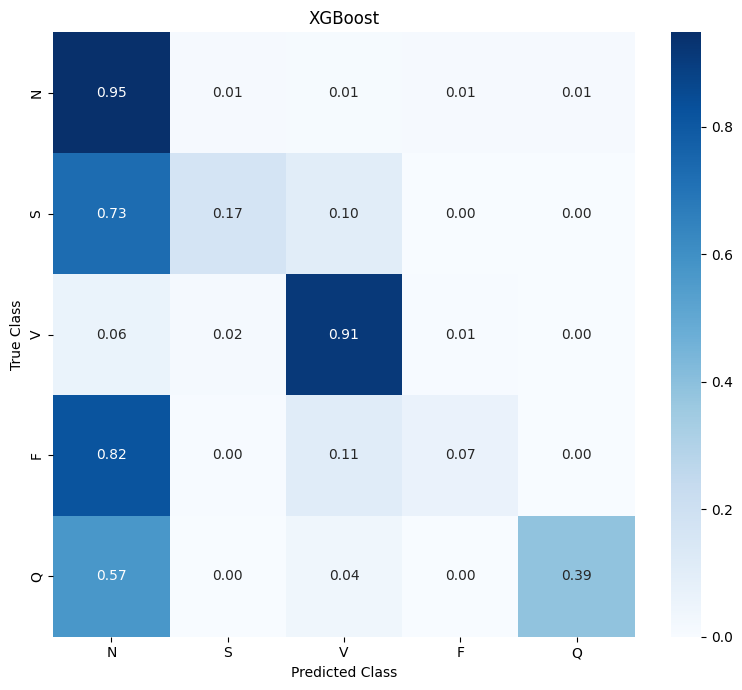

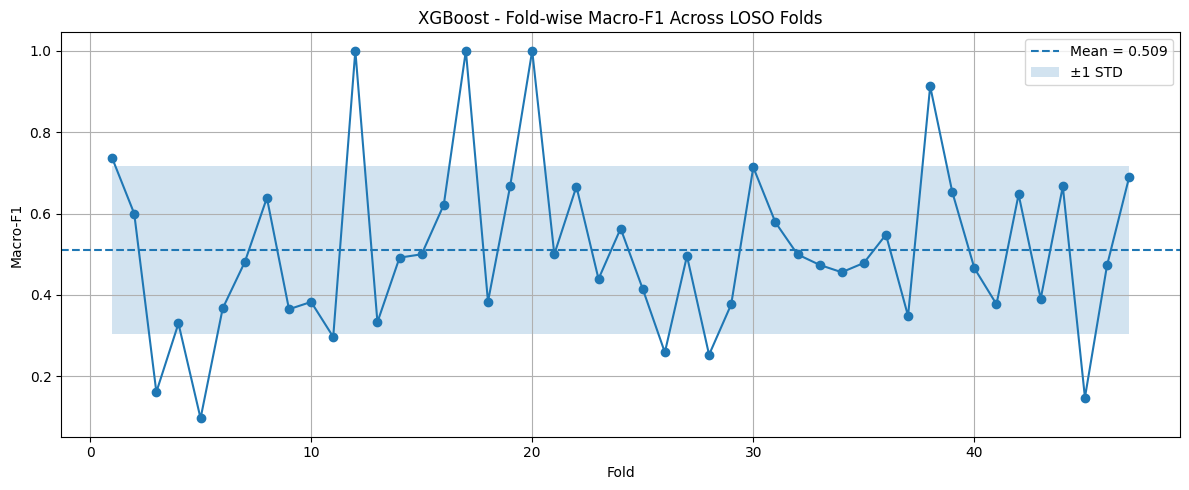

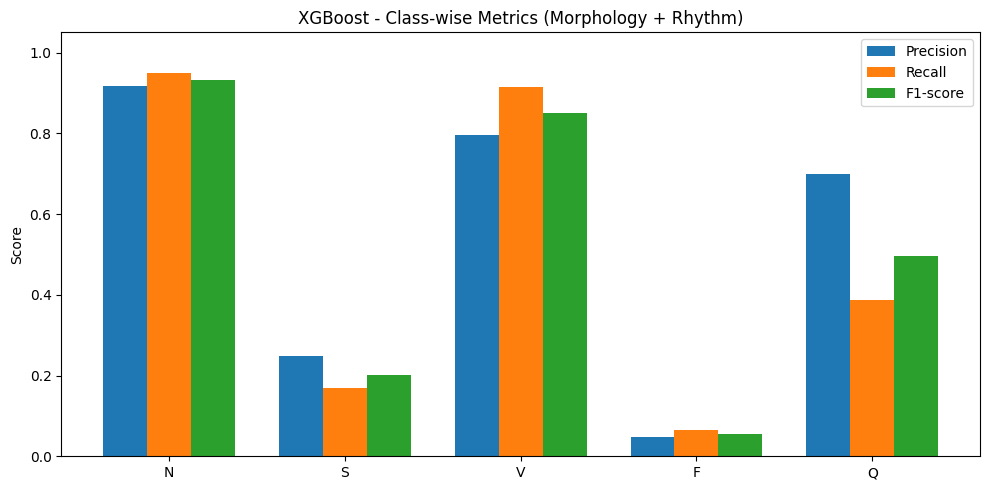

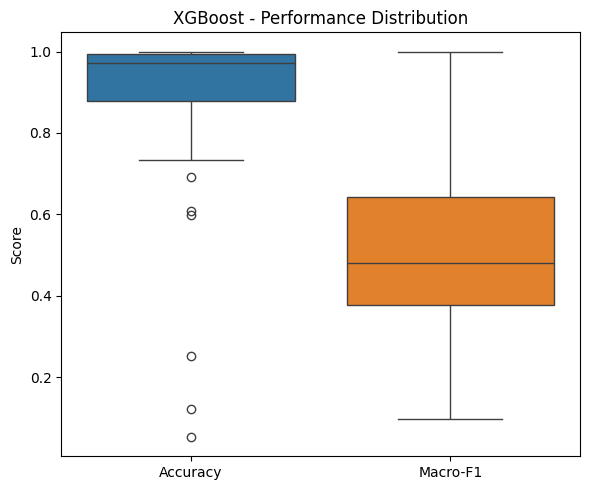

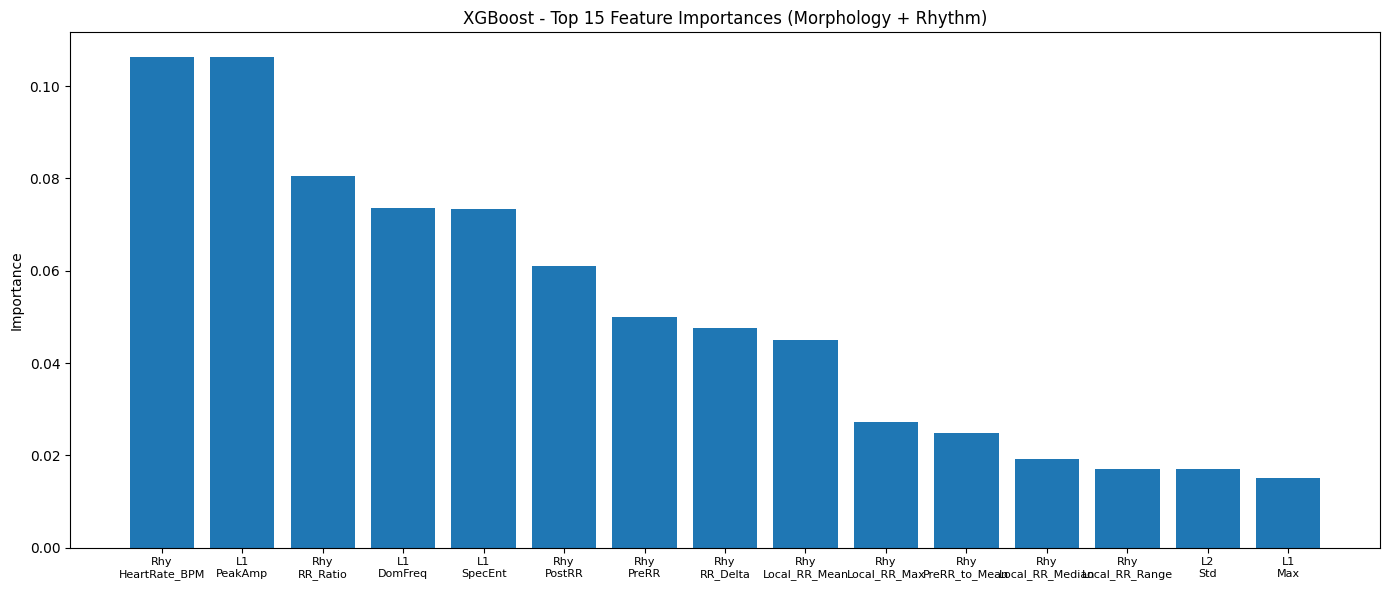

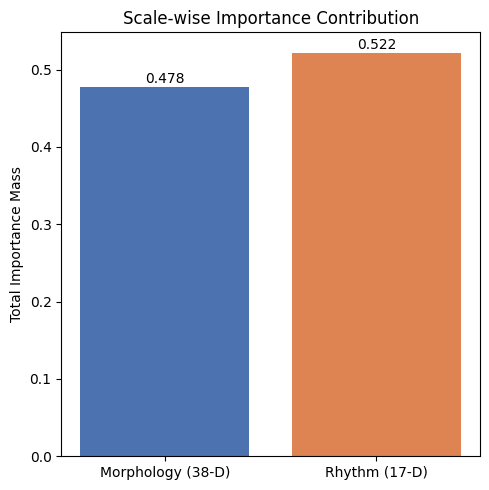

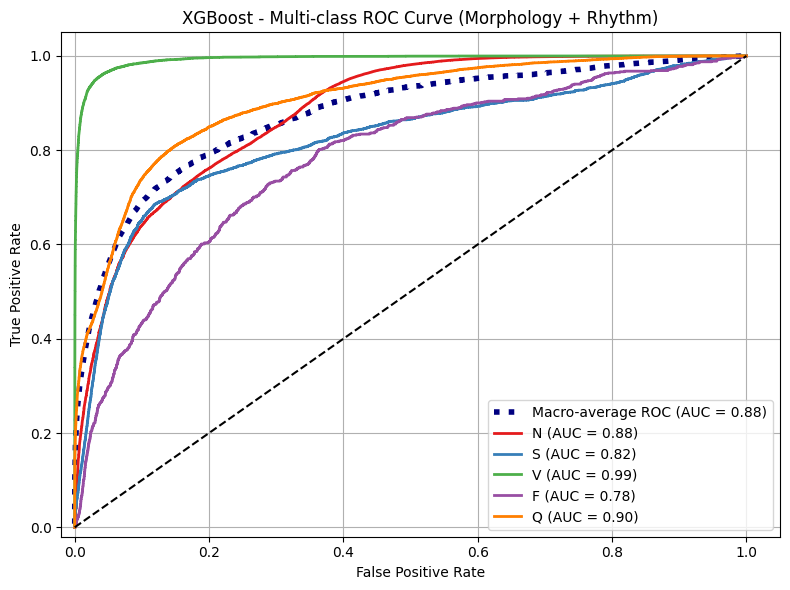


FINAL LOSO PERFORMANCE (MORPHOLOGY 38-D + RHYTHM 17-D)
Overall Accuracy : 0.8786
Overall Macro-F1 : 0.5073


In [6]:
# ============================================================
# STEP-06: Aggregate LOSO Results + Visualization
#          XGBoost (Morphology 38-D + True Rhythm 17-D = 55-D)
# ============================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# ------------------------------------------------------------
# Class Names
# ------------------------------------------------------------
CLASS_NAMES = ["N", "S", "V", "F", "Q"]

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------
os.makedirs("results_xgb", exist_ok=True)

# ------------------------------------------------------------
# Aggregate predictions
# ------------------------------------------------------------
all_preds  = np.concatenate([np.asarray(r["preds"])  for r in all_results])
all_labels = np.concatenate([np.asarray(r["labels"]) for r in all_results])
all_probs  = np.concatenate([np.asarray(r["probs"])  for r in all_results])

# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------
overall_acc = accuracy_score(all_labels, all_preds)
overall_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)

report_dict = classification_report(
    all_labels, all_preds, labels=[0,1,2,3,4],
    target_names=CLASS_NAMES, zero_division=0, output_dict=True
)

agg_cm = confusion_matrix(all_labels, all_preds, labels=[0,1,2,3,4])

print("=" * 60)
print("XGBOOST — OVERALL LOSO RESULTS (MORPHOLOGY + RHYTHM)")
print("=" * 60)
print(f"Overall Accuracy : {overall_acc:.4f}")
print(f"Overall Macro-F1 : {overall_f1:.4f}")
print("\nClassification Report\n")
print(classification_report(
    all_labels, all_preds, labels=[0,1,2,3,4],
    target_names=CLASS_NAMES, zero_division=0
))

# ------------------------------------------------------------
# Fold statistics
# ------------------------------------------------------------
fold_accuracies = [r["accuracy"] for r in all_results]
fold_macro_f1s  = [r["macro_f1"] for r in all_results]

mean_acc = float(np.mean(fold_accuracies))
std_acc  = float(np.std(fold_accuracies))
mean_f1  = float(np.mean(fold_macro_f1s))
std_f1   = float(np.std(fold_macro_f1s))

mean_n_estimators = float(np.mean([r["n_estimators"] for r in all_results]))
mean_max_depth    = float(np.mean([r["max_depth"]    for r in all_results]))

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------
with open("results_xgb/all_results.pkl", "wb") as f:
    pickle.dump(all_results, f)
print("Saved: results_xgb/all_results.pkl")

summary = {
    "model": "XGBClassifier (Morphology 38-D + Rhythm 17-D = 55-D)",
    "overall_accuracy": float(overall_acc),
    "overall_macro_f1": float(overall_f1),
    "classification_report": report_dict,
    "aggregate_confusion_matrix": agg_cm.tolist(),
    "fold_accuracies": fold_accuracies,
    "fold_macro_f1s": fold_macro_f1s,
    "mean_n_estimators": mean_n_estimators,
    "mean_max_depth": mean_max_depth
}

with open("results_xgb/summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: results_xgb/summary.json")

# ============================================================
# Plot 1: Normalized Confusion Matrix
# ============================================================
cm_norm = agg_cm.astype(np.float64) / (agg_cm.sum(axis=1, keepdims=True) + 1e-8)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title("XGBoost")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig("results_xgb/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 2: Fold-wise Macro-F1
# ============================================================
fold_nums = [r["fold"] for r in all_results]

plt.figure(figsize=(12, 5))
plt.plot(fold_nums, fold_macro_f1s, marker="o")
plt.axhline(mean_f1, linestyle="--", label=f"Mean = {mean_f1:.3f}")
plt.fill_between(
    fold_nums, mean_f1 - std_f1, mean_f1 + std_f1,
    alpha=0.20, label="±1 STD"
)
plt.title("XGBoost - Fold-wise Macro-F1 Across LOSO Folds")
plt.xlabel("Fold")
plt.ylabel("Macro-F1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("results_xgb/fold_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 3: Class-wise Precision / Recall / F1
# ============================================================
precision = [report_dict[c]["precision"] for c in CLASS_NAMES if c in report_dict]
recall    = [report_dict[c]["recall"]    for c in CLASS_NAMES if c in report_dict]
f1_scores = [report_dict[c]["f1-score"]  for c in CLASS_NAMES if c in report_dict]

x = np.arange(len(CLASS_NAMES))
w = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - w, precision, width=w, label="Precision")
plt.bar(x,     recall,    width=w, label="Recall")
plt.bar(x + w, f1_scores, width=w, label="F1-score")
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("XGBoost - Class-wise Metrics (Morphology + Rhythm)")
plt.legend()
plt.tight_layout()
plt.savefig("results_xgb/classwise_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 4: Performance Distribution
# ============================================================
df = pd.DataFrame({
    "Accuracy": fold_accuracies,
    "Macro-F1": fold_macro_f1s
})

plt.figure(figsize=(6, 5))
sns.boxplot(data=df)
plt.title("XGBoost - Performance Distribution")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("results_xgb/performance_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 5: Feature Importance (Morphology 38-D + Rhythm 17-D)
# ============================================================

# ---- Intra-beat MORPHOLOGY names (18 per lead) ----
INTRA_NAMES_PER_LEAD = [
    "Mean", "Std", "Min", "Max", "Range", "Median",
    "Skew", "Kurtosis", "RMS", "Energy",
    "PeakAmp", "PeakPos", "ZCR", "MAD",
    "DomFreq", "SpecEnt", "IQR", "Slope"
]

# ---- Inter-beat RHYTHM names (17 total) ----
# Order EXACTLY matches extract_rhythm_features() in Step-04
RHYTHM_NAMES = [
    "PreRR", "PostRR", "RR_Ratio", "RR_Delta",                    # 1–4
    "Local_RR_Mean", "Local_RR_Std", "Local_RR_Median",           # 5–7
    "Local_RR_Min",  "Local_RR_Max",  "Local_RR_Range",           # 8–10
    "Local_RR_IQR",                                               # 11
    "RMSSD", "pNN50", "RR_CV",                                    # 12–14
    "PreRR_to_Mean", "PostRR_to_Mean",                            # 15–16
    "HeartRate_BPM"                                               # 17
]

# ---- Build 55-D name list ----
FEATURE_NAMES = []
for f in INTRA_NAMES_PER_LEAD:
    FEATURE_NAMES.append(f"L1\n{f}")
for f in INTRA_NAMES_PER_LEAD:
    FEATURE_NAMES.append(f"L2\n{f}")
FEATURE_NAMES.append("Cross\nCorr")
FEATURE_NAMES.append("Cross\nDiff")
for f in RHYTHM_NAMES:
    FEATURE_NAMES.append(f"Rhy\n{f}")

assert len(FEATURE_NAMES) == 55, (
    f"Feature name list length mismatch: expected 55, got {len(FEATURE_NAMES)}"
)

# ---- Average importances across folds ----
importance_list = []
for r in all_results:
    fi = np.asarray(r["feature_importances"], dtype=np.float32)
    if len(fi) == len(FEATURE_NAMES):
        importance_list.append(fi)

if len(importance_list) > 0:
    avg_importance = np.mean(np.vstack(importance_list), axis=0)

    top_idx   = np.argsort(avg_importance)[::-1][:15]
    top_vals  = avg_importance[top_idx]
    top_names = [FEATURE_NAMES[i] for i in top_idx]

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(top_vals)), top_vals)
    plt.xticks(range(len(top_vals)), top_names, fontsize=8, rotation=0)
    plt.title("XGBoost - Top 15 Feature Importances (Morphology + Rhythm)")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.savefig("results_xgb/feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ---- Scale-wise total importance ----
    morph_mass  = float(np.sum(avg_importance[:38]))   # 36 lead + 2 cross
    rhythm_mass = float(np.sum(avg_importance[38:]))   # 17 rhythm

    plt.figure(figsize=(5, 5))
    plt.bar(
        ["Morphology (38-D)", "Rhythm (17-D)"],
        [morph_mass, rhythm_mass],
        color=["#4C72B0", "#DD8452"]
    )
    plt.ylabel("Total Importance Mass")
    plt.title("Scale-wise Importance Contribution")
    for i, v in enumerate([morph_mass, rhythm_mass]):
        plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig("results_xgb/scale_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Feature importance plot skipped (length mismatch).")

# ============================================================
# Plot 6: Multi-class ROC Curve (One-vs-Rest)
# ============================================================
classes        = [0, 1, 2, 3, 4]
all_labels_bin = label_binarize(all_labels, classes=classes)
n_classes      = all_labels_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"]     = all_fpr
tpr["macro"]     = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 6))
plt.plot(
    fpr["macro"], tpr["macro"],
    label=f"Macro-average ROC (AUC = {roc_auc['macro']:.2f})",
    color="navy", linestyle=":", linewidth=4
)

colors = sns.color_palette("Set1", n_classes)
for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], "k--", lw=1.5)
plt.xlim([-0.02, 1.05])
plt.ylim([-0.02, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost - Multi-class ROC Curve (Morphology + Rhythm)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("results_xgb/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# FINAL LOSO PERFORMANCE
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("FINAL LOSO PERFORMANCE (MORPHOLOGY 38-D + RHYTHM 17-D)")
print("=" * 60)
print(f"Overall Accuracy : {overall_acc:.4f}")
print(f"Overall Macro-F1 : {overall_f1:.4f}")
print("=" * 60)